In [1]:
import csv
import sys

import matplotlib.pyplot as plt
import numpy as np
import scipy
from matplotlib import colors
from pruning.matrices import (
    Qsym_cellphy10,
    Qsym_gtr4,
    Qsym_gtr10,
    Qsym_gtr10z,
    Qsym_GTRsq,
    Qsym_GTRxGTR,
    Qsym_unphased,
    gtr10_rate,
)
import ete3

from sklearn.decomposition import PCA
from sklearn import linear_model

In [2]:
csvs_10K = [
    "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-unphased.csv",
    "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-cellphy.csv",
    "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-gtr10z.csv",
    "/home/knappa/pruning/data/diploid-sites-10000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-gtr10.csv",
]

csvs_1K = [
    "/home/knappa/pruning/data/diploid-sites-1000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-unphased.csv",
    "/home/knappa/pruning/data/diploid-sites-1000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-cellphy.csv",
    "/home/knappa/pruning/data/diploid-sites-1000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-gtr10z.csv",
    "/home/knappa/pruning/data/diploid-sites-1000-seq-err-0.00-ado-0.00/combined-fit-stats-reconstructed-tree-gtr10.csv",
]
models = ["UNPHASED_DNA", "CELLPHY", "GTR10Z", "GTR10"]

In [3]:
def get_data(filename):
    raw_data = []
    with open(filename, "r") as csv_file:
        csvreader = csv.reader(csv_file)
        # noinspection PyUnusedLocal
        headers = next(csvreader)
        for line in csvreader:
            raw_data.append(list(map(float, line)))
    data = np.array(raw_data)
    return data


def get_Qs(data, model):
    num_examples = data.shape[0]
    # noinspection PyUnreachableCode
    match model:
        case "DNA":
            pis = data[:, 1:5]
            Ss = data[:, 5:]
            Q_function = Qsym_gtr4
        case "PHASED_DNA16":
            pis = data[:, 1:17]
            Ss = data[:, 17:]
            Q_function = Qsym_GTRsq
        case "PHASED_DNA16_MP":
            pis = data[:, 1:17]
            Ss = data[:, 17:]
            Q_function = Qsym_GTRxGTR
        case "UNPHASED_DNA":
            pis = data[:, 1:11]
            Ss = data[:, 11:]
            Q_function = Qsym_unphased
        case "CELLPHY":
            pis = data[:, 1:11]
            Ss = data[:, 11:]
            Q_function = Qsym_cellphy10
        case "GTR10Z":
            pis = data[:, 1:11]
            Ss = data[:, 11:]
            Q_function = Qsym_gtr10z
        case "GTR10" | "RAXML-NG":
            pis = data[:, 1:11]
            Ss = data[:, 11:]
            Q_function = Qsym_gtr10
        case _:
            assert False

    if model == "RAXML-NG":
        scale = np.array(
            [gtr10_rate(pis[ex_idx, :], Ss[ex_idx, :]) / 2.0 for ex_idx in range(num_examples)]
        )
    else:
        scale = np.ones(num_examples)

    Qs = np.array(
        [
            np.diag(1 / np.sqrt(pis[ex_idx, :]))
            @ Q_function(pis[ex_idx, :], Ss[ex_idx, :])
            @ np.diag(np.sqrt(pis[ex_idx, :]))
            / scale[ex_idx]
            for ex_idx in range(num_examples)
        ]
    )
    return Qs

In [4]:
true_pis = np.array(
    [0.085849, 0.04, 0.042849, 0.09, 0.1172, 0.121302, 0.1758, 0.0828, 0.12, 0.1242]
)
true_pi16s = np.array(
    [
        0.085849,
        0.0586,
        0.060651,
        0.0879,
        0.0586,
        0.04,
        0.0414,
        0.06,
        0.060651,
        0.0414,
        0.042849,
        0.0621,
        0.0879,
        0.06,
        0.0621,
        0.09,
    ]
)
true_params = np.array([0.839, 0.112, 2.239, 0.600, 3.119, 0.560])

In [5]:
true_Q = get_Qs(np.concatenate(([0], true_pis, true_params))[np.newaxis, :], "UNPHASED_DNA")

In [6]:
Qs_1K = []
for csvfile, model in zip(csvs_1K, models):
    Qs_1K.append(get_Qs(get_data(csvfile), model))
Qs_1K = np.array(Qs_1K)

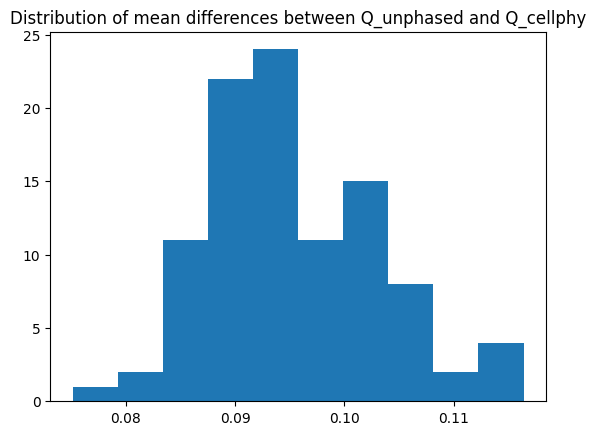

In [7]:
ts = np.linspace(0,40,400)

distances = np.array([
    np.mean(np.abs(Qs_1K[0,idx,:,:] - Qs_1K[1,idx,:,:])) for idx in range(100)
])

plt.hist(distances)
plt.title("Distribution of mean differences between Q_unphased and Q_cellphy")

plt.show()

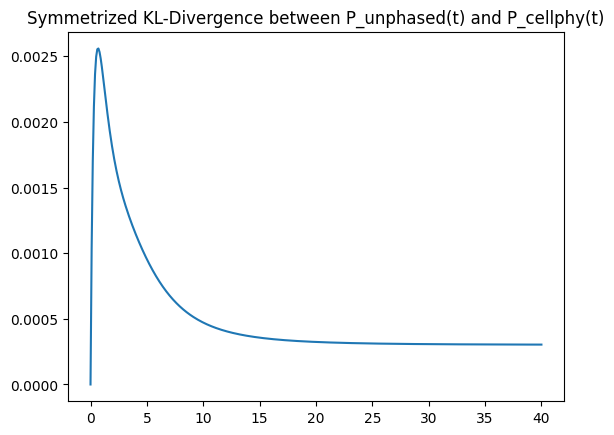

Max distance at t=0.7017543859649122


In [8]:
ts = np.linspace(0,40,400)

distances = np.zeros((100,ts.shape[0]), dtype=np.float64)

for idx in range(100):
    for t_idx, t in enumerate(ts):
        distances[idx,t_idx] = (
            0.5 * np.mean(
                scipy.special.kl_div(
                    scipy.linalg.expm(t*Qs_1K[0,idx,:,:]).reshape(-1),
                    scipy.linalg.expm(t*Qs_1K[1,idx,:,:]).reshape(-1)
                ) + 
                scipy.special.kl_div(
                    scipy.linalg.expm(t*Qs_1K[1,idx,:,:]).reshape(-1),
                    scipy.linalg.expm(t*Qs_1K[0,idx,:,:]).reshape(-1)
                )
            )
        )

mean_distances = np.mean(distances, axis=0)

plt.plot(ts, mean_distances)
plt.title("Symmetrized KL-Divergence between P_unphased(t) and P_cellphy(t)")
plt.show()


max_loc = np.argmax(mean_distances)
print(f"Max distance at t={ts[max_loc]}")

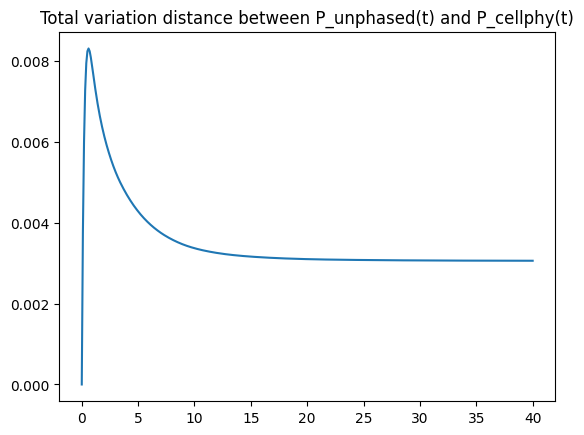

Max distance at t=0.6015037593984962


In [9]:
ts = np.linspace(0,40,400)

distances = np.zeros((100,ts.shape[0]), dtype=np.float64)

for idx in range(100):
    for t_idx, t in enumerate(ts):
        distances[idx,t_idx] = 0.5*(
            np.mean(
                np.abs(scipy.linalg.expm(t*Qs_1K[0,idx,:,:]).reshape(-1) -
                    scipy.linalg.expm(t*Qs_1K[1,idx,:,:]).reshape(-1))
            )
        )

mean_distances = np.mean(distances, axis=0)

plt.plot(ts, mean_distances)
plt.title("Total variation distance between P_unphased(t) and P_cellphy(t)")
plt.show()

max_loc = np.argmax(mean_distances)
print(f"Max distance at t={ts[max_loc]}")

In [10]:
dists = []
for idx in range(100):
    t = ete3.Tree(f'/home/knappa/pruning/data/diploid-sites-1000-seq-err-0.00-ado-0.00/tree-{str(idx).zfill(3)}.nwk')
    q = [t]
    while len(q) > 0:
        n = q[0]
        q = q[1:]
        dists.append(n.dist)
        for c in n.children:
            q.append(c)

print(f"Mean branch length = {np.mean(dists)}")
print(f"Max branch length = {np.max(dists)}")
print(f"Min branch length = {np.min(dists)}")

Mean branch length = 0.00013045497487437183
Max branch length = 0.000409
Min branch length = 0.0


In [11]:
t = np.max(dists)
max_tav = np.mean(
                np.abs(scipy.linalg.expm(t*Qs_1K[0,idx,:,:]).reshape(-1) -
                    scipy.linalg.expm(t*Qs_1K[1,idx,:,:]).reshape(-1))
)
print(f"Maximum total absolute variation at max branch len = {max_tav}")

Maximum total absolute variation at max branch len = 4.042863555460937e-05


In [12]:
all_tavs = np.array([
     np.mean(
                np.abs(scipy.linalg.expm(t*Qs_1K[0,idx,:,:]).reshape(-1) -
                    scipy.linalg.expm(t*Qs_1K[1,idx,:,:]).reshape(-1))
    ) 
    for t in dists])

print(f"Maximum total absolute variation over all branch lengths displayed in trees = {max(all_tavs)}")

Maximum total absolute variation over all branch lengths displayed in trees = 4.042863555460937e-05


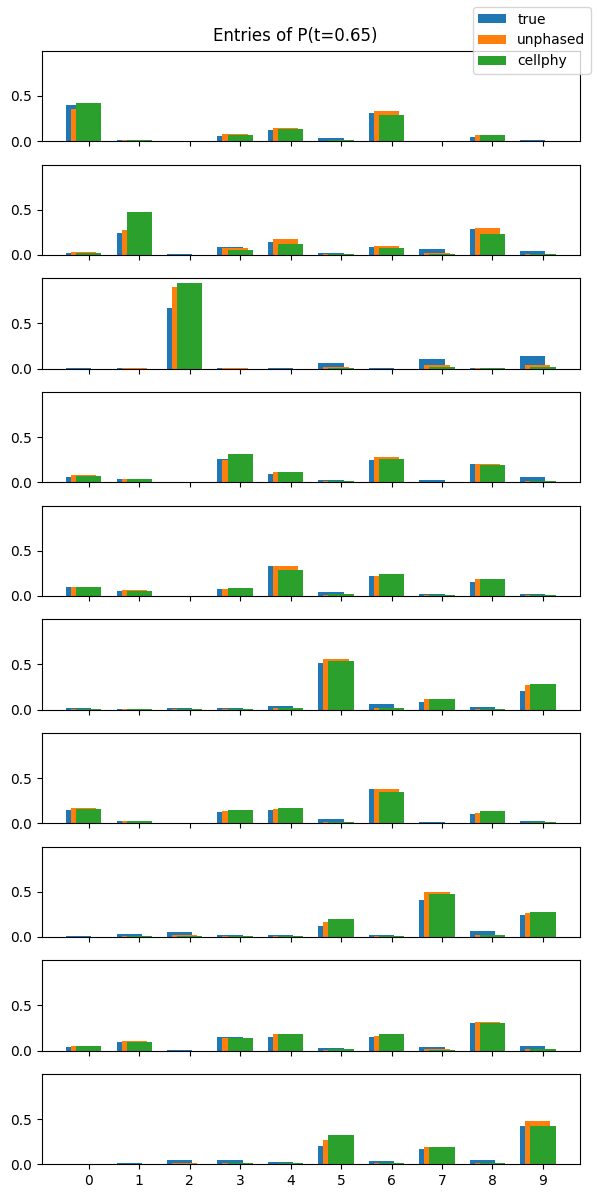

In [13]:
fig, axs = plt.subplots(10,1, figsize=(6,12), sharey=True, sharex=True)

t= 0.65
example_idx = 0

true_P = scipy.linalg.expm(t*true_Q)[0,:,:]
unphased_P = scipy.linalg.expm(t*Qs_1K[0,example_idx,:,:])
cellphy_P = scipy.linalg.expm(t*Qs_1K[1,example_idx,:,:])

for row in range(10):
    axs[row].bar(np.arange(10), true_P[row,:], width=0.5, tick_label=list(map(str, range(10))), label="true")
    axs[row].bar(np.arange(10)+0.1, unphased_P[row,:], width=0.5, tick_label=list(map(str, range(10))), label="unphased")
    axs[row].bar(np.arange(10)+0.2, cellphy_P[row,:], width=0.5, tick_label=list(map(str, range(10))), label="cellphy")

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys())
fig.suptitle(f"Entries of P({t=})")
fig.tight_layout()

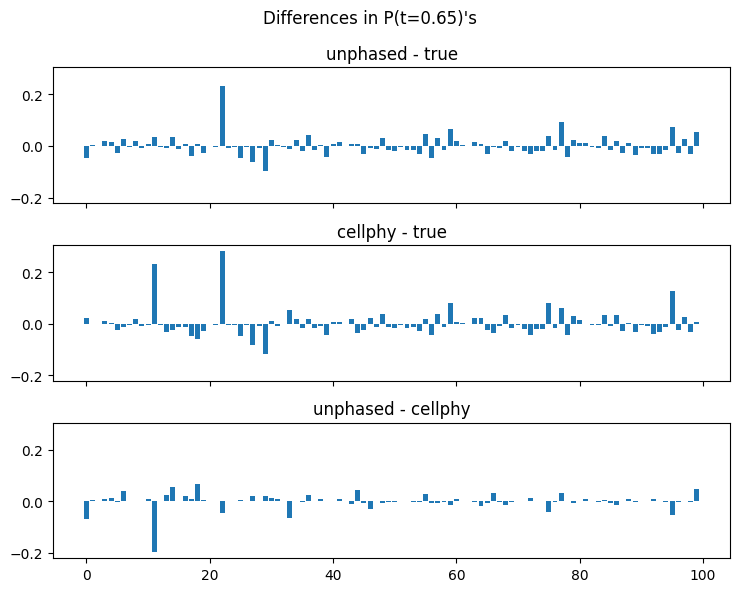

In [14]:
fig, axs = plt.subplots(3,1, figsize=(7.5,6), sharey=True, sharex=True)

t = 0.65
true_P = scipy.linalg.expm(t*true_Q)[0,:,:]
unphased_P = scipy.linalg.expm(t*Qs_1K[0,0,:,:])
cellphy_P = scipy.linalg.expm(t*Qs_1K[1,0,:,:])

axs[0].bar(np.arange(100), (unphased_P - true_P).reshape(-1))
axs[0].set_title("unphased - true")

axs[1].bar(np.arange(100), (cellphy_P - true_P).reshape(-1))
axs[1].set_title("cellphy - true")

axs[2].bar(np.arange(100), (unphased_P - cellphy_P).reshape(-1))
axs[2].set_title("unphased - cellphy")

fig.suptitle(f"Differences in P({t=})'s")
fig.tight_layout()

In [15]:
unphased_params = get_data(csvs_1K[0])[:, 11:]
unphased_pis = get_data(csvs_1K[0])[:, 1:11]

cellphy_params = get_data(csvs_1K[1])[:, 11:]
cellphy_pis = get_data(csvs_1K[1])[:, 1:11]

gtr10z_params = get_data(csvs_1K[2])[:, 11:]
gtr10z_pis = get_data(csvs_1K[2])[:, 1:11]

gtr10_params = get_data(csvs_1K[3])[:, 11:]
gtr10_pis = get_data(csvs_1K[3])[:, 1:11]

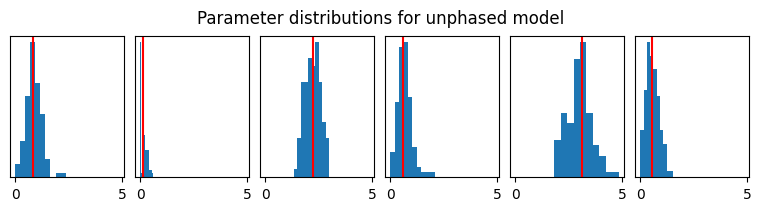

In [16]:
fig, axs = plt.subplots(1,6, sharex=True, figsize=(7.5,2), layout='constrained')


for param_idx in range(6):
    axs[param_idx].hist(unphased_params[:,param_idx]) #, density=True)
    axs[param_idx].set_yticks([])
    axs[param_idx].axvline(true_params[param_idx], color='red')

fig.suptitle(f"Parameter distributions for unphased model")

plt.show()

In [17]:
def pi10s_to_pi4s(pi10s):
    """
    Convert 10 state frequencies to 4 state frequencies

    :param pi10s: 10 state frequencies
    :return:
    """
    pi_aa, pi_cc, pi_gg, pi_tt, pi_ac, pi_ag, pi_at, pi_cg, pi_ct, pi_gt = pi10s

    pi_a = pi_aa + pi_ac / 2 + pi_ag / 2 + pi_at / 2
    pi_c = pi_ac / 2 + pi_cc + pi_cg / 2 + pi_ct / 2
    pi_g = pi_ag / 2 + pi_cg / 2 + pi_gg + pi_gt / 2
    pi_t = pi_at / 2 + pi_ct / 2 + pi_gt / 2 + pi_tt
    return np.array([pi_a, pi_c, pi_g, pi_t])
    

def unphased_to_gtr10z(pi10s, rate_params):
    pi_a, pi_c, pi_g, pi_t = pi10s_to_pi4s(pi10s)
    s_ac, s_ag, s_at, s_cg, s_ct, s_gt = np.abs(rate_params)

    return np.array(
        [
            s_ac / pi_a,
            s_ag / pi_a,
            s_at / pi_a,
            s_ac / pi_c,
            s_cg / pi_c,
            s_ct / pi_c,
            s_ag / pi_g,
            s_cg / pi_g,
            s_gt / pi_g,
            s_at / pi_t,
            s_ct / pi_t,
            s_gt / pi_t,
            s_cg / (2 * pi_a),
            s_ct / (2 * pi_a),
            s_ag / (2 * pi_c),
            s_at / (2 * pi_c),
            s_gt / (2 * pi_a),
            s_ac / (2 * pi_g),
            s_at / (2 * pi_g),
            s_ac / (2 * pi_t),
            s_ag / (2 * pi_t),
            s_gt / (2 * pi_c),
            s_ct / (2 * pi_g),
            s_cg / (2 * pi_t),
        ]
    )

true_to_gtr10z_params = unphased_to_gtr10z(true_pis, true_params)
unphased_to_gtr10z_params = unphased_to_gtr10z(unphased_pis.T, unphased_params.T).T

In [18]:
def cellphy_to_gtr10z(rate_params):
    sc_1, sc_2, sc_3, sc_4, sc_5, sc_6 = np.abs(rate_params)

    return np.array([
         sc_1,
         sc_2,
         sc_3,
         sc_1,
         sc_4,
         sc_5,
         sc_2,
         sc_4,
         sc_6,
         sc_3,
         sc_5,
         sc_6,
         sc_4,
         sc_5,
         sc_2,
         sc_3,
         sc_6,
         sc_1,
         sc_3,
         sc_1,
         sc_2,
         sc_6,
         sc_5,
         sc_4
        ]
    )

cellphy_to_gtr10z_params = cellphy_to_gtr10z(cellphy_params.T).T

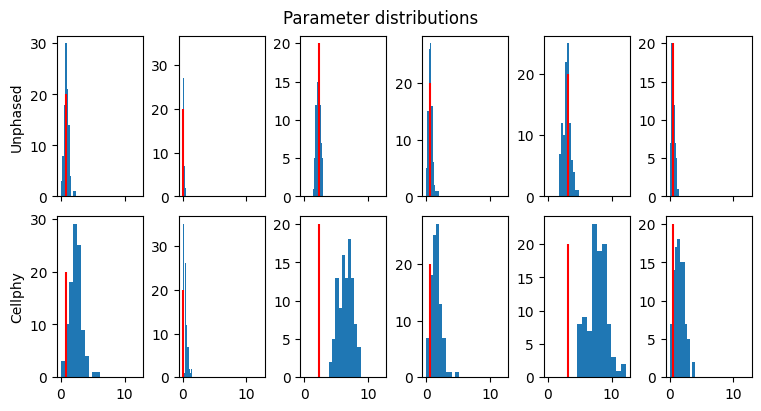

In [19]:
fig, axs = plt.subplots(2,6, sharex=True, figsize=(7.5,4), layout='constrained')


for param_idx in range(6):
    axs[0,param_idx].hist(unphased_params[:,param_idx]) #, density=True)
    # axs[0,param_idx].set_yticks([])
    axs[0,param_idx].vlines([true_params[param_idx]], 0, 20, color='red')

axs[0,0].set_ylabel("Unphased")

for param_idx in range(6):
    axs[1,param_idx].hist(cellphy_params[:,param_idx]) #, density=True)
    # axs[1,param_idx].set_yticks([])
    axs[1,param_idx].vlines([true_params[param_idx]], 0, 20, color='red')

axs[1,0].set_ylabel("Cellphy")

fig.suptitle(f"Parameter distributions")

plt.show()

In [20]:
gtr10z_params.shape

(100, 24)

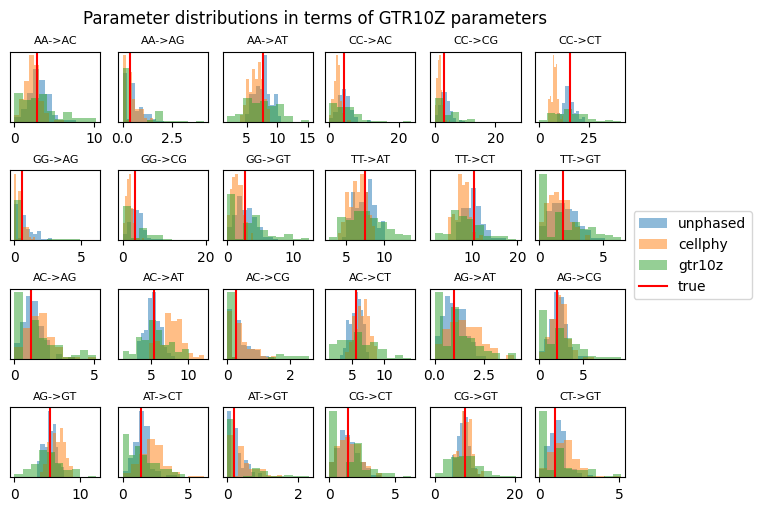

In [21]:
# fig, axs = plt.subplots(4,6, sharex=True, figsize=(7.5,4), layout='constrained')
fig, axs = plt.subplots(4,6, figsize=(7.5,5), layout='constrained')

rate_labels = [
    "AA->AC",
    "AA->AG",
    "AA->AT",
    "CC->AC",
    "CC->CG",
    "CC->CT",
    "GG->AG",
    "GG->CG",
    "GG->GT",
    "TT->AT",
    "TT->CT",
    "TT->GT",
    "AC->AG",
    "AC->AT",
    "AC->CG",
    "AC->CT",
    "AG->AT",
    "AG->CG",
    "AG->GT",
    "AT->CT",
    "AT->GT",
    "CG->CT",
    "CG->GT",
    "CT->GT",
]

for param_idx in range(24):
    axs[param_idx // 6,param_idx % 6].hist(unphased_to_gtr10z_params[:,param_idx], density=True, alpha=0.5, label="unphased")
    axs[param_idx // 6,param_idx % 6].hist(cellphy_to_gtr10z_params[:,param_idx], density=True, alpha=0.5, label="cellphy")
    axs[param_idx // 6,param_idx % 6].hist(gtr10z_params[:,param_idx], density=True, alpha=0.5, label="gtr10z")
    axs[param_idx // 6,param_idx % 6].axvline(true_to_gtr10z_params[param_idx], color='red', label="true")
    axs[param_idx // 6,param_idx % 6].set_yticks([])
    axs[param_idx // 6,param_idx % 6].set_title(rate_labels[param_idx], size=8)
    

fig.suptitle(f"Parameter distributions in terms of GTR10Z parameters                         ")

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='outside center right')

plt.show()

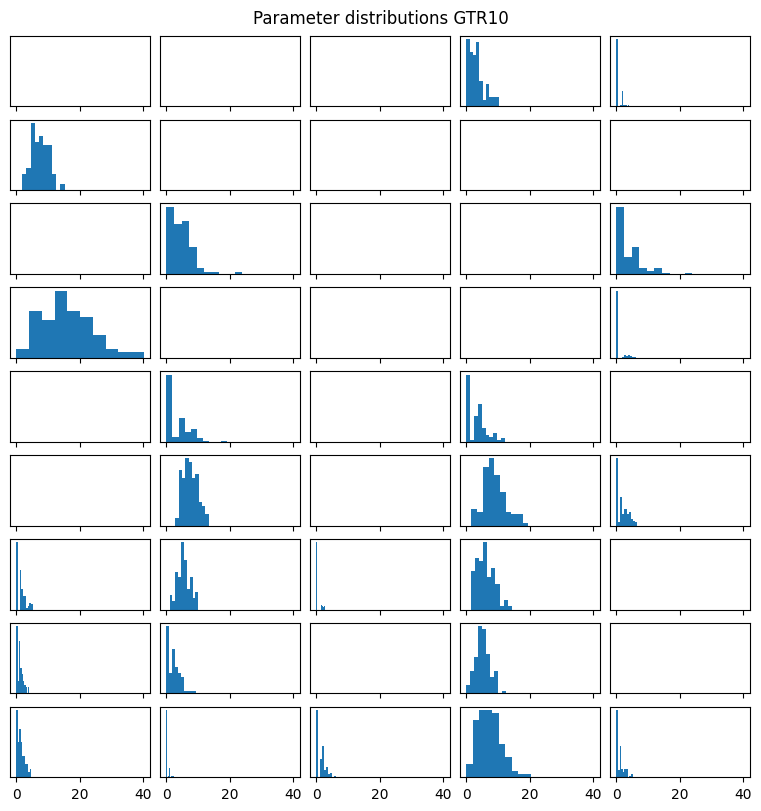

In [22]:
fig, axs = plt.subplots(9,5, sharex=True, figsize=(7.5,8), layout='constrained')


for param_idx in range(45):
    axs[param_idx // 5,param_idx % 5].hist(gtr10_params[:,param_idx], density=True)
    axs[param_idx // 5,param_idx % 5].set_yticks([])
    

# for param_idx in range(45, 8*6):
#     axs[param_idx // 5,param_idx % 5].axis("off")

fig.suptitle(f"Parameter distributions GTR10")

plt.show()

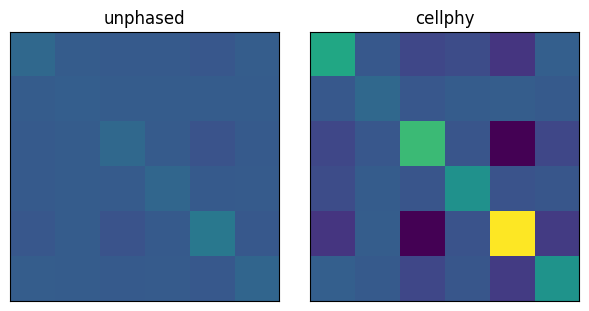

In [23]:
fig, axs = plt.subplots(1,2, sharex=True, figsize=(6,3), layout='constrained')

unph_cov = np.cov(unphased_params, rowvar=False)
cp_cov  = np.cov(cellphy_params, rowvar=False)
gtr10z_cov  = np.cov(gtr10z_params, rowvar=False)
gtr10_cov  = np.cov(gtr10_params, rowvar=False)

plt_max = max(np.max(unph_cov), np.max(cp_cov))
plt_min = min(np.min(unph_cov), np.min(cp_cov))


axs[0].imshow(unph_cov, vmin=plt_min, vmax=plt_max)
axs[0].set_title("unphased")
axs[0].set_xticks([])
axs[0].set_yticks([])

axs[1].imshow(cp_cov, vmin=plt_min, vmax=plt_max)
axs[1].set_title("cellphy")
axs[1].set_xticks([])
axs[1].set_yticks([])

plt.show()

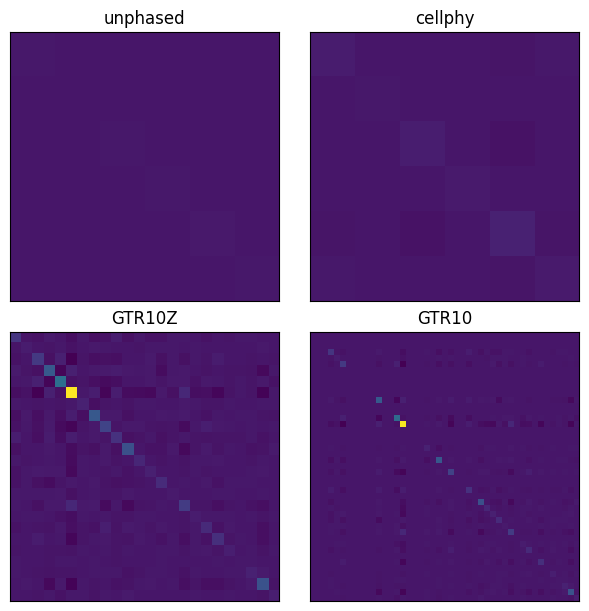

In [24]:
fig, axs = plt.subplots(2,2, figsize=(6,6), layout='constrained')

plt_max = max(np.max(unph_cov), np.max(cp_cov), np.max(gtr10z_cov), np.max(gtr10_cov))
plt_min = min(np.min(unph_cov), np.min(cp_cov), np.min(gtr10z_cov), np.min(gtr10_cov))

axs[0,0].imshow(unph_cov, vmin=plt_min, vmax=plt_max)
axs[0,0].set_title("unphased")
axs[0,0].set_xticks([])
axs[0,0].set_yticks([])

axs[0,1].imshow(cp_cov, vmin=plt_min, vmax=plt_max)
axs[0,1].set_title("cellphy")
axs[0,1].set_xticks([])
axs[0,1].set_yticks([])

axs[1,0].imshow(gtr10z_cov, vmin=plt_min, vmax=plt_max)
axs[1,0].set_title("GTR10Z")
axs[1,0].set_xticks([])
axs[1,0].set_yticks([])

axs[1,1].imshow(gtr10_cov, vmin=plt_min, vmax=plt_max)
axs[1,1].set_title("GTR10")
axs[1,1].set_xticks([])
axs[1,1].set_yticks([])

plt.show()

In [25]:
print(f"Singular values for unphased covariance:\n {np.linalg.svd(unph_cov, compute_uv=False)}")
print(f"Singular values for cellphy covariance:\n {np.linalg.svd(cp_cov, compute_uv=False)}")
print(f"Singular values for gtr10z covariance:\n {np.linalg.svd(gtr10z_cov, compute_uv=False)}")
print(f"Singular values for gtr10 covariance:\n {np.linalg.svd(gtr10_cov, compute_uv=False)}")

Singular values for unphased covariance:
 [0.401908   0.18134765 0.13410915 0.10257099 0.02642959 0.00290936]
Singular values for cellphy covariance:
 [2.76819793 1.33146197 0.83768289 0.65711787 0.18219093 0.02116962]
Singular values for gtr10z covariance:
 [69.02923102 24.58214967 17.04129641 16.08275581 14.16484033 12.41336669
 10.47158931  9.14118172  8.01254225  5.36627656  5.13824679  4.38956401
  3.47809761  2.72499425  2.21011343  1.82389172  1.51980188  1.40711218
  1.26737966  0.87862035  0.72289279  0.48486258  0.3138152   0.09316501]
Singular values for gtr10 covariance:
 [6.82421074e+01 2.37833892e+01 1.71543992e+01 1.60889474e+01
 1.41568055e+01 1.23819862e+01 1.04751115e+01 9.18241251e+00
 7.98352824e+00 5.36199250e+00 5.12285557e+00 4.39665554e+00
 3.48164736e+00 2.72768518e+00 2.19240502e+00 1.83239867e+00
 1.51985840e+00 1.40921182e+00 1.25421374e+00 8.76085038e-01
 7.21330061e-01 4.87077682e-01 3.13432939e-01 9.31955432e-02
 1.32117631e-15 9.70229151e-16 9.41092852e-

In [26]:
s = np.linalg.svd(unph_cov, compute_uv=False)

print(f"Unphased model: Proportion of variance explained by singular values:\n {s / sum(s)}")

Unphased model: Proportion of variance explained by singular values:
 [0.47323672 0.21353238 0.1579102  0.12077481 0.03112019 0.0034257 ]


In [27]:
s = np.linalg.svd(cp_cov, compute_uv=False)

print(f"Cellphy model: Proportion of variance explained by singular values:\n {s / sum(s)}")

Cellphy model: Proportion of variance explained by singular values:
 [0.47745486 0.22964868 0.14448236 0.11333876 0.03142403 0.00365131]


In [28]:
s = np.linalg.svd(gtr10z_cov, compute_uv=False)

with np.printoptions(suppress=True):
    print(f"GTR10Z model: Proportion of variance explained by singular values:\n {s / sum(s)}")

GTR10Z model: Proportion of variance explained by singular values:
 [0.32444984 0.11554054 0.08009717 0.07559186 0.06657731 0.05834506
 0.04921836 0.0429652  0.03766039 0.02522247 0.02415069 0.02063174
 0.01634769 0.01280796 0.01038793 0.00857262 0.00714334 0.00661368
 0.00595691 0.00412967 0.00339773 0.00227894 0.00147499 0.00043789]


In [29]:
s = np.linalg.svd(gtr10_cov, compute_uv=False)

with np.printoptions(suppress=True):
    print(f"GTR10 model: Proportion of variance explained by singular values:\n {s / sum(s)}")

GTR10 model: Proportion of variance explained by singular values:
 [0.32305679 0.1125901  0.08120859 0.07616476 0.06701804 0.05861608
 0.04958897 0.04346936 0.03779387 0.02538357 0.0242515  0.02081368
 0.01648205 0.01291281 0.0103788  0.00867454 0.00719498 0.00667118
 0.00593742 0.00414737 0.00341476 0.00230582 0.00148379 0.00044119
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.        ]


In [30]:
pca = PCA(n_components=2)
pca.fit(np.concatenate((unphased_params, cellphy_params), axis=0))

print(pca.explained_variance_ratio_)

[0.79290639 0.09971669]


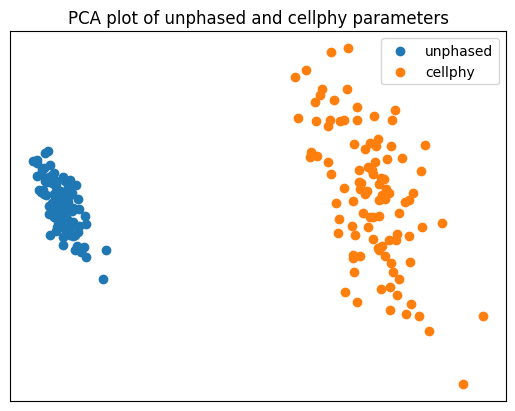

In [31]:
plt.scatter(*zip(*pca.transform(unphased_params)), label='unphased')
plt.scatter(*zip(*pca.transform(cellphy_params)), label='cellphy')
plt.title("PCA plot of unphased and cellphy parameters")

# zero_pos = pca.transform([np.zeros(6)])[0]
# vecs = pca.transform(np.identity(6))
# for idx in range(6):
#     plt.annotate(
#         "", 
#         xytext=(0,0),
#         xy=vecs[idx,:]-zero_pos,
#         arrowprops=dict(arrowstyle="->")
#     )

plt.xticks([])
plt.yticks([])
plt.legend()
plt.show()

In [32]:
pca = PCA(n_components=3)
pca.fit(np.concatenate((unphased_params, cellphy_params), axis=0))

print(pca.explained_variance_ratio_)

[0.79290639 0.09971669 0.04608002]


/home/knappa/pruning/venv/lib/python3.11/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/home/knappa/pruning/venv/lib/python3.11/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


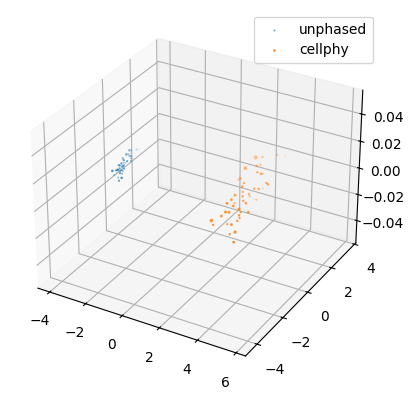

In [33]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

plt.scatter(*zip(*pca.transform(unphased_params)), label='unphased')
plt.scatter(*zip(*pca.transform(cellphy_params)), label='cellphy')

plt.legend()
plt.show()

[0.47323672 0.21353238]


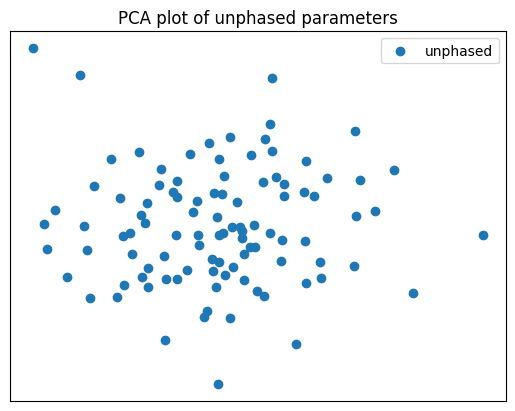

In [34]:
pca = PCA(n_components=2)
pca.fit(unphased_params)

print(pca.explained_variance_ratio_)

plt.scatter(*zip(*pca.transform(unphased_params)), label='unphased')
plt.title("PCA plot of unphased parameters")
plt.xticks([])
plt.yticks([])
plt.legend()
plt.show()

[0.47745486 0.22964868]


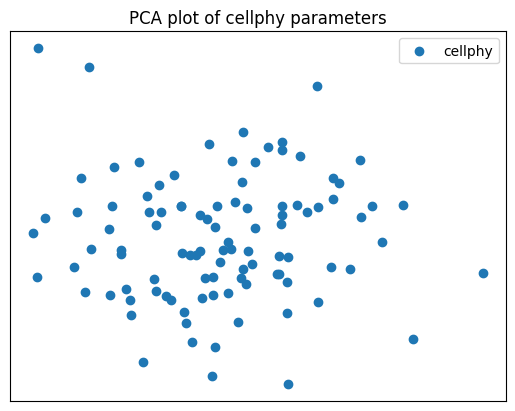

In [35]:
pca = PCA(n_components=2)
pca.fit(cellphy_params)

print(pca.explained_variance_ratio_)

plt.scatter(*zip(*pca.transform(cellphy_params)), label='cellphy')
plt.title("PCA plot of cellphy parameters")
plt.xticks([])
plt.yticks([])
plt.legend()
plt.show()

# 10K

In [36]:
Qs_10K = []
for csvfile, model in zip(csvs_10K, models):
    Qs_10K.append(get_Qs(get_data(csvfile), model))
Qs_10K = np.array(Qs_10K)

In [37]:
unphased_params = get_data(csvs_10K[0])[:, 11:]
cellphy_params = get_data(csvs_10K[1])[:, 11:]
gtr10z_params = get_data(csvs_10K[2])[:, 11:]
gtr10_params = get_data(csvs_10K[3])[:, 11:]

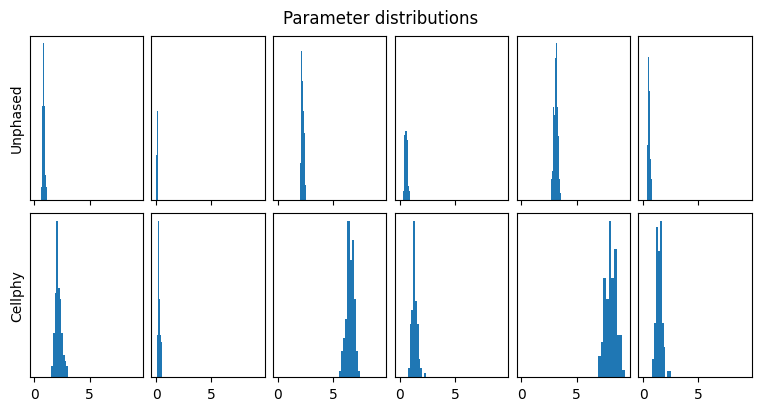

In [38]:
fig, axs = plt.subplots(2,6, sharex=True, figsize=(7.5,4), layout='constrained')


for param_idx in range(6):
    axs[0,param_idx].hist(unphased_params[:,param_idx])
    axs[0,param_idx].set_yticks([])

axs[0,0].set_ylabel("Unphased")

for param_idx in range(6):
    axs[1,param_idx].hist(cellphy_params[:,param_idx])
    axs[1,param_idx].set_yticks([])

axs[1,0].set_ylabel("Cellphy")

fig.suptitle(f"Parameter distributions")

plt.show()

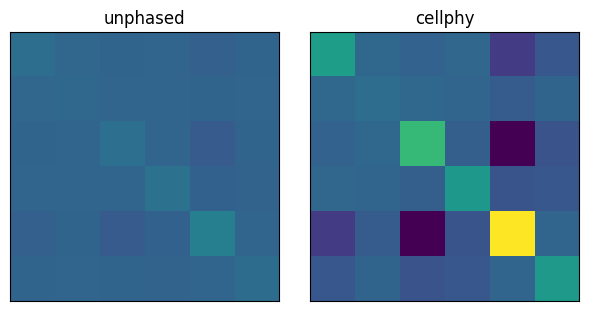

In [39]:
fig, axs = plt.subplots(1,2, sharex=True, figsize=(6,3), layout='constrained')

unph_cov = np.cov(unphased_params, rowvar=False)
cp_cov  = np.cov(cellphy_params, rowvar=False)

plt_max = max(np.max(unph_cov), np.max(cp_cov))
plt_min = min(np.min(unph_cov), np.min(cp_cov))


axs[0].imshow(unph_cov, vmin=plt_min, vmax=plt_max)
axs[0].set_title("unphased")
axs[0].set_xticks([])
axs[0].set_yticks([])

axs[1].imshow(cp_cov, vmin=plt_min, vmax=plt_max)
axs[1].set_title("cellphy")
axs[1].set_xticks([])
axs[1].set_yticks([])

plt.show()

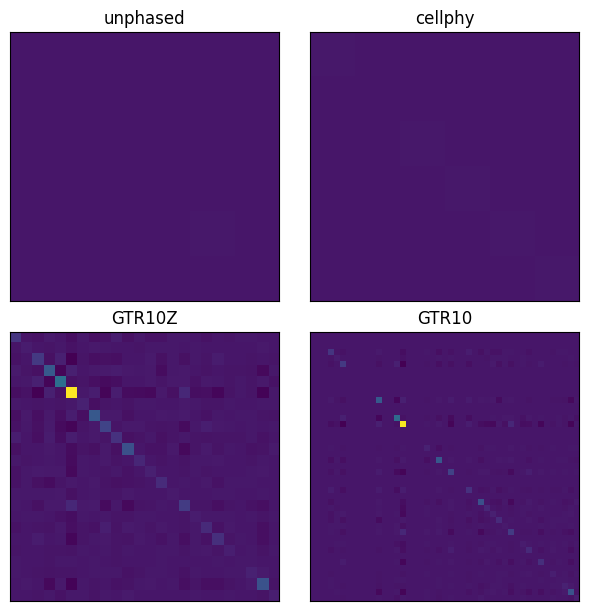

In [40]:
fig, axs = plt.subplots(2,2, figsize=(6,6), layout='constrained')

plt_max = max(np.max(unph_cov), np.max(cp_cov), np.max(gtr10z_cov), np.max(gtr10_cov))
plt_min = min(np.min(unph_cov), np.min(cp_cov), np.min(gtr10z_cov), np.min(gtr10_cov))

axs[0,0].imshow(unph_cov, vmin=plt_min, vmax=plt_max)
axs[0,0].set_title("unphased")
axs[0,0].set_xticks([])
axs[0,0].set_yticks([])

axs[0,1].imshow(cp_cov, vmin=plt_min, vmax=plt_max)
axs[0,1].set_title("cellphy")
axs[0,1].set_xticks([])
axs[0,1].set_yticks([])

axs[1,0].imshow(gtr10z_cov, vmin=plt_min, vmax=plt_max)
axs[1,0].set_title("GTR10Z")
axs[1,0].set_xticks([])
axs[1,0].set_yticks([])

axs[1,1].imshow(gtr10_cov, vmin=plt_min, vmax=plt_max)
axs[1,1].set_title("GTR10")
axs[1,1].set_xticks([])
axs[1,1].set_yticks([])

plt.show()

In [41]:
s = np.linalg.svd(unph_cov, compute_uv=False)

print(f"Unphased model: Proportion of variance explained by singular values:\n {s / sum(s)}")

Unphased model: Proportion of variance explained by singular values:
 [0.51587947 0.18669707 0.15868876 0.11352847 0.02143864 0.00376757]


In [42]:
s = np.linalg.svd(cp_cov, compute_uv=False)

print(f"Cellphy model: Proportion of variance explained by singular values:\n {s / sum(s)}")

Cellphy model: Proportion of variance explained by singular values:
 [0.5351779  0.17048697 0.14834845 0.12012291 0.02094046 0.00492332]


In [43]:
s = np.linalg.svd(gtr10z_cov, compute_uv=False)

with np.printoptions(suppress=True):
    print(f"GTR10Z model: Proportion of variance explained by singular values:\n {s / sum(s)}")

GTR10Z model: Proportion of variance explained by singular values:
 [0.32444984 0.11554054 0.08009717 0.07559186 0.06657731 0.05834506
 0.04921836 0.0429652  0.03766039 0.02522247 0.02415069 0.02063174
 0.01634769 0.01280796 0.01038793 0.00857262 0.00714334 0.00661368
 0.00595691 0.00412967 0.00339773 0.00227894 0.00147499 0.00043789]


In [44]:
s = np.linalg.svd(gtr10_cov, compute_uv=False)

with np.printoptions(suppress=True):
    print(f"GTR10 model: Proportion of variance explained by singular values:\n {s / sum(s)}")

GTR10 model: Proportion of variance explained by singular values:
 [0.32305679 0.1125901  0.08120859 0.07616476 0.06701804 0.05861608
 0.04958897 0.04346936 0.03779387 0.02538357 0.0242515  0.02081368
 0.01648205 0.01291281 0.0103788  0.00867454 0.00719498 0.00667118
 0.00593742 0.00414737 0.00341476 0.00230582 0.00148379 0.00044119
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.        ]


In [45]:
pca = PCA(n_components=2)
pca.fit(np.concatenate((unphased_params, cellphy_params), axis=0))

print(pca.explained_variance_ratio_)

[0.97354926 0.0141695 ]


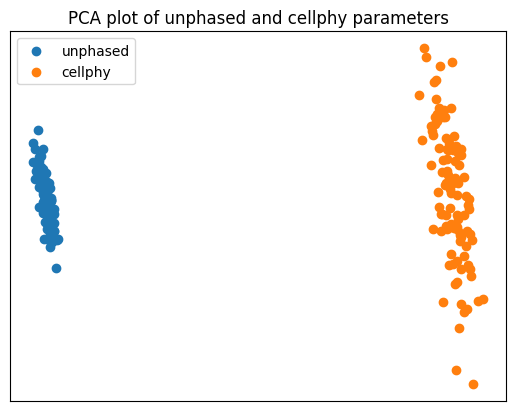

In [46]:
plt.scatter(*zip(*pca.transform(unphased_params)), label='unphased')
plt.scatter(*zip(*pca.transform(cellphy_params)), label='cellphy')
plt.title("PCA plot of unphased and cellphy parameters")
plt.xticks([])
plt.yticks([])
plt.legend()
plt.show()

# Transforming between models

In [47]:
reg = linear_model.LinearRegression()

reg.fit(unphased_params, cellphy_params)

print(f"coefficient matrix:\n{reg.coef_}")
print(f"intercepts:\n{reg.intercept_}")

coefficient matrix:
[[ 2.72029396e+00  1.63099101e-01  2.75761943e-01  1.65914301e-01
   1.50434454e-01  1.40962024e-01]
 [ 3.23141860e-02  2.61777746e+00  4.37916532e-02  2.02271170e-02
   2.97558008e-02  3.15473910e-02]
 [-2.40872194e-01 -9.00299213e-02  1.97868506e+00 -8.53093245e-01
  -3.84330390e-01 -4.57545149e-01]
 [ 3.26942979e-02  1.47729839e-01 -3.58057307e-01  1.85248704e+00
  -5.77393870e-02 -1.05978958e-01]
 [-2.20081801e-01 -2.79307252e-01  2.78340503e-01  5.69685033e-01
   2.43294049e+00  2.44594284e-03]
 [ 1.11702349e-01  3.55341646e-02  5.43387101e-01  5.44414072e-01
   1.59170181e-01  2.85298899e+00]]
intercepts:
[-1.42255252 -0.25293839  4.28548577  1.24671638 -0.2662828  -2.26518074]


In [48]:
from sklearn import linear_model

reg = linear_model.Lasso(alpha=0.001)

reg.fit(unphased_params, cellphy_params)

print(f"coefficient matrix:\n{reg.coef_}")
print(f"intercepts:\n{reg.intercept_}")

coefficient matrix:
[[ 2.4729622  -0.          0.          0.         -0.01926191 -0.        ]
 [ 0.          1.94952227 -0.         -0.         -0.00374192 -0.        ]
 [ 0.          0.          2.27359955 -0.59470293 -0.13713564 -0.08774831]
 [ 0.02879513  0.         -0.20339589  1.83470117 -0.         -0.        ]
 [-0.2802216  -0.          0.02170183  0.43754117  2.28268373 -0.02646054]
 [-0.11121948 -0.          0.08431249  0.27093938 -0.09697224  2.44312244]]
intercepts:
[0.12992213 0.08070463 2.27838937 0.6910954  0.89215997 0.14722585]


In [49]:
model_text = {
    "DNA": "DNA",
    "PHASED_DNA16": "Phased DNA",
    "PHASED_DNA16_MP": "Phased DNA M/P rates vary",
    "UNPHASED_DNA": "Unphased DNA",
    "CELLPHY": "Cellphy",
    "GTR10Z": "GTR10Z",
    "GTR10": "GTR10",
    "RAXML-NG": "RAXML-NG",
}

n_states = {
    "DNA": 4,
    "PHASED_DNA16": 16,
    "PHASED_DNA16_MP": 16,
    "UNPHASED_DNA": 10,
    "CELLPHY": 10,
    "GTR10Z": 10,
    "GTR10": 10,
    "RAXML-NG": 10,
}

In [50]:
cmap = plt.get_cmap("BrBG").copy()
cmap.set_bad(color="black")
cmap.set_under(color="black")


def make_norm(plot_max, power, centered=True):
    def _forward(x):
        return np.sign(x) * np.abs(x) ** power

    def _inverse(x):
        return np.sign(x) * np.abs(x) ** (1 / power)

    if centered:
        return colors.FuncNorm((_forward, _inverse), vmin=-plot_max, vmax=plot_max)
    else:
        return colors.FuncNorm((_forward, _inverse), vmin=0.0, vmax=plot_max)